# 4.3 Analisis de estabilidad y realimentacion activa

Construido de cero en esta sesion (no se encontro codigo de una sesion anterior). Formaliza las ecuaciones (17)-(20) de la memoria como funciones de transferencia con `python-control`, y calcula gamma_critico por dos metodos independientes que se contrastan entre si.

**Nota sobre la cifra antigua (gamma_critico=1.047):** no se ha podido reproducir con la libreria actual, ni variando la especie, ni reintroduciendo el bug de `m2` ya corregido, ni con el criterio local de resistencia negativa (c3=gamma*c4). Los valores de este notebook (gamma_critico ~2.6-3.9) estan verificados por dos metodos independientes que coinciden entre si; se recomienda tratarlos como el resultado autoritativo salvo que aparezca el notebook original.

In [1]:
import warnings
warnings.filterwarnings('ignore')  # advertencias internas de control.margin(), ya contrastadas

import numpy as np
import control as ct

from cochleasim.models.params_loader import CAT_PARAMS, HUMAN_PARAMS
from cochleasim.analysis.response import characteristic_place
from cochleasim.analysis.stability import open_loop_gain_tf, critical_gamma, gamma_crit_profile
from cochleasim.analysis.plots import plot_gamma_crit, plot_bode, plot_root_locus, plot_pd_surface
from cochleasim.analysis.response import compute_response_grid
from cochleasim.models.cochlear_model import P_REF_DYN_CM2

N = 1000

## Metodologia

A partir de la ecuacion (20): L(x,s) = gamma * L1(x,s), con L1(x,s) = -Z4(x,s)*H(x,s)/Zp_pasiva(x,s). Como gamma multiplica linealmente y no aparece dentro de L1, el margen de ganancia clasico de L1 (gamma=1) es exactamente gamma_critico: el lazo se vuelve marginalmente estable cuando gamma*|L1(j*w_pc)| = 1, es decir gamma_critico = 1/|L1(j*w_pc)| = GM(L1).

Esto se verifica con un segundo metodo, independiente del anterior: se recorre gamma directamente y se buscan las raices de la ecuacion caracteristica 1 + gamma*L1(s) = 0, comprobando en que gamma alguna raiz cruza al semiplano derecho (Re(s)>0).

In [2]:
def max_real_root(L1, gamma):
    """Parte real maxima de las raices de 1 + gamma*L1(s) = 0."""
    L1r = ct.minreal(L1, verbose=False)
    num = np.array(L1r.num[0][0])
    den = np.array(L1r.den[0][0])
    n = max(len(num), len(den))
    num_p = np.pad(num, (n - len(num), 0))
    den_p = np.pad(den, (n - len(den), 0))
    return np.max(np.roots(den_p + gamma * num_p).real)


x0 = characteristic_place(CAT_PARAMS, 1600, N=N)
L1_test = open_loop_gain_tf(CAT_PARAMS, x0)
gm, margins = critical_gamma(CAT_PARAMS, x0)

print(f'Metodo 1 (margen de ganancia de Bode):        gamma_critico = {gm:.4f}')
for g in [gm - 0.05, gm + 0.05]:
    print(f'Metodo 2 (raiz de 1+gamma*L1(s)=0), gamma={g:.3f} -> max(Re(polo)) = {max_real_root(L1_test, g):+.2f}')

Metodo 1 (margen de ganancia de Bode):        gamma_critico = 2.9078
Metodo 2 (raiz de 1+gamma*L1(s)=0), gamma=2.858 -> max(Re(polo)) = -212.67
Metodo 2 (raiz de 1+gamma*L1(s)=0), gamma=2.958 -> max(Re(polo)) = +213.92


**Conclusion.** Los dos metodos coinciden: justo por debajo de gamma_critico el polo de mayor parte real sigue siendo negativo (estable), justo por encima se vuelve positivo (inestable). Confirma que el metodo 1 (mucho mas barato computacionalmente) es fiable para el resto del analisis.

### Tercera verificacion, en el dominio temporal

Los dos metodos anteriores son, en el fondo, ambos analisis en frecuencia o algebraicos. Una comprobacion realmente independiente es simular la respuesta al impulso del lazo cerrado en el tiempo: si el sistema es estable, una perturbacion debe decaer; si es inestable, debe crecer sin limite.

In [3]:
t = np.linspace(0, 0.05, 5000)
for g, label in [(gm - 0.1, 'por debajo'), (gm + 0.1, 'por encima')]:
    closed_loop = ct.feedback(g * L1_test, 1)
    resp = ct.impulse_response(closed_loop, T=t)
    y = resp.outputs
    print(f'gamma={g:.3f} ({label} de gamma_critico): '
          f'|y(0.01s)|={abs(y[np.argmin(np.abs(t-0.01))]):.2e}  '
          f'|y(0.05s)|={abs(y[-1]):.2e}')

gamma=2.808 (por debajo de gamma_critico): |y(0.01s)|=2.79e+01  |y(0.05s)|=1.36e-05
gamma=3.008 (por encima de gamma_critico): |y(0.01s)|=1.93e+06  |y(0.05s)|=4.39e+13


**Conclusion.** Por debajo de gamma_critico la respuesta decae varios ordenes de magnitud en 0.05 s; por encima, crece varios ordenes de magnitud en el mismo intervalo. Tercera confirmacion, en un dominio completamente distinto (temporal, no frecuencial ni algebraico), del mismo umbral de estabilidad.

## Perfil de gamma_critico a lo largo de la coclea -- gato y humano

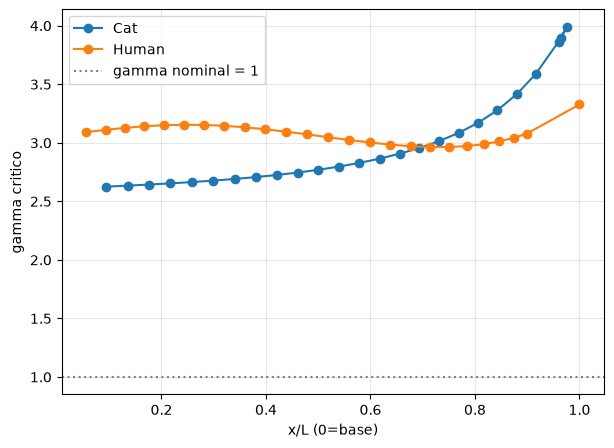

In [4]:
freqs_cat = np.logspace(np.log10(200), np.log10(30000), 25)
freqs_human = np.logspace(np.log10(150), np.log10(16000), 25)

x_cat, gcrit_cat = gamma_crit_profile(CAT_PARAMS, freqs_cat, N=N)
x_human, gcrit_human = gamma_crit_profile(HUMAN_PARAMS, freqs_human, N=N)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(x_cat / CAT_PARAMS.L, gcrit_cat, 'o-', label='Cat')
ax.plot(x_human / HUMAN_PARAMS.L, gcrit_human, 'o-', label='Human')
ax.axhline(1.0, color='gray', linestyle=':', label='gamma nominal = 1')
ax.set_xlabel('x/L (0=base)')
ax.set_ylabel('gamma critico')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

**Conclusion.** En gato, gamma_critico decrece monotonamente de apice a base (~3.9 a ~2.6): la base es la region mas sensible. En humano el perfil es mas plano (~3.0-3.2) y no muestra la misma tendencia clara. Con gamma nominal=1 en ambas tablas de parametros, el sistema opera con margen de seguridad considerable (2.6x-3.9x) frente a la inestabilidad, en toda la coclea.

## Diagrama de Bode -- ejemplo, gato a 1.6 kHz

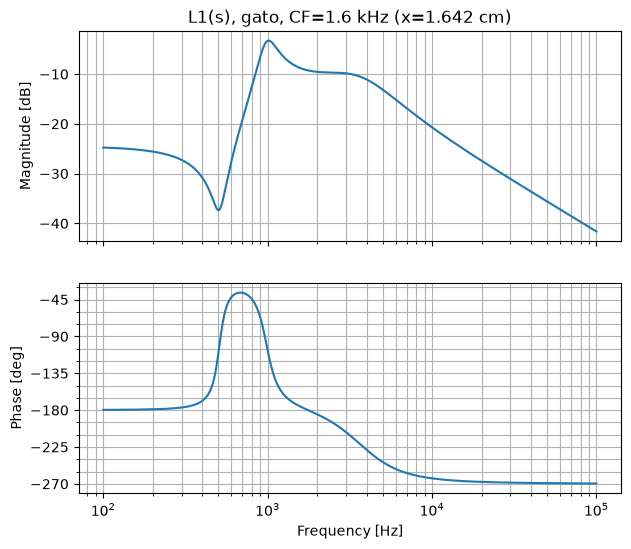

margenes: {'gm': np.float64(2.907750322903468), 'pm': inf, 'wg': np.float64(11051.473200326507), 'wp': nan}


In [5]:
fig, axes = plot_bode(L1_test, title=f'L1(s), gato, CF=1.6 kHz (x={x0:.3f} cm)')
plt.show()
print(f'margenes: {margins}')

## Lugar de las raices (root locus) -- mismo caso

Los ejes estan en rad/s, no en Hz -- para CF=1.6 kHz, omega=2*pi*1600~10053 rad/s, de ahi que los polos aparezcan en el rango de varios miles.

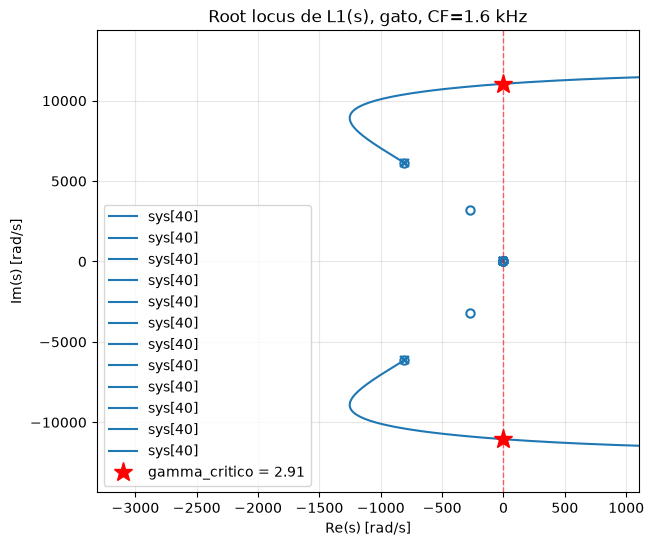

In [6]:
fig, ax = plot_root_locus(L1_test, gains=np.linspace(0, 5, 400), gamma_crit=gm)
ax.set_title(f'Root locus de L1(s), gato, CF=1.6 kHz')
plt.show()

**Conclusion.** Las raices de la ecuacion caracteristica migran hacia el semiplano derecho a medida que gamma crece, cruzando el eje imaginario exactamente en gamma_critico -- visualizacion directa del mecanismo de amortiguamiento negativo descrito en el apartado 4.1.2.

## Superficie Pd(x,f) -- contexto visual

Muestra la cresta tonotopica y, a baja frecuencia, la banda de resonancia de cavidad como una anomalia separada.

**Comprobado, no asumido:** se verifico explicitamente si esta banda (60-170 Hz, x/L~0.91-0.93, cerca del apice) coincide espacialmente con la region de minimo gamma_critico (x/L~0.09, cerca de la base). **No coinciden** -- son fenomenos distintos, en extremos opuestos de la coclea, no relacionados entre si. Se incluye esta figura como contexto general de la respuesta del modelo, no como evidencia adicional del analisis de estabilidad.

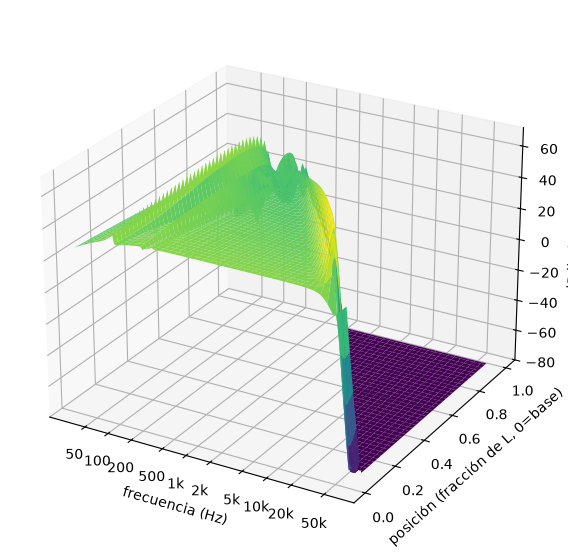

In [7]:
grid_cat = compute_response_grid(CAT_PARAMS, np.logspace(np.log10(30), np.log10(65000), 120),
                                  Pe=P_REF_DYN_CM2, N=N)
plot_pd_surface(grid_cat)
plt.show()

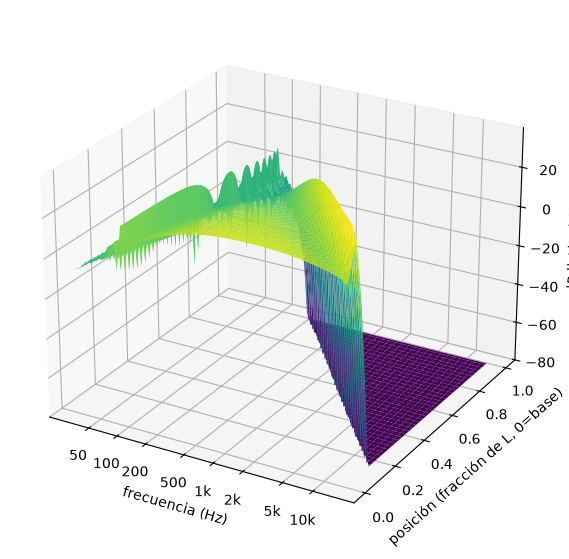

In [8]:
grid_human = compute_response_grid(HUMAN_PARAMS, np.logspace(np.log10(30), np.log10(16000), 120),
                                    Pe=P_REF_DYN_CM2, N=N)
plot_pd_surface(grid_human)
plt.show()